# Analyse des relation entre les labels , genre musical et les récompences

In [1]:
### Librairies externes à ajouter le cas échéant à l'environnement Python actif

from SPARQLWrapper import SPARQLWrapper, JSON, TURTLE, XML, RDFXML

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
import networkx as nx

### Librairies déjà installées avec Python

import pprint
import csv
import sys

from importlib import reload



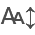

In [2]:
### Module de visualisation de données
#  https://mwouts.github.io/itables/quick_start.html

from itables import init_notebook_mode, show

init_notebook_mode(all_interactive=False)

In [3]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')


import sparql_functions as spqf

## Importer les donnée à analyser

In [36]:
## define SPARQL enpoint
endpoint_url = "https://ag13s8z3wvmae0kr.allegrograph.cloud/repositories/rappers"   # À adapter si nécessaire
graph_uri = "https://github.com/Ziedellouzi/rappers/blob/main/graphs/wikidata-imported-data.md"


In [4]:
# Importation des bibliothèques nécessaires
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd

# Définir la fonction pour exécuter la requête SPARQL
def run_sparql_query(query):
    """
    Fonction pour exécuter une requête SPARQL sur l'endpoint AllegroGraph et récupérer les résultats.
    """
    endpoint_url = "https://ag13s8z3wvmae0kr.allegrograph.cloud/repositories/rappers"
    sparql = SPARQLWrapper(endpoint_url)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    return sparql.query().convert()

# Requête SPARQL pour récupérer les rappeurs avec leurs genres, labels et récompenses
query = """
PREFIX wdt: <http://www.wikidata.org/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?rapper ?rapperLabel (GROUP_CONCAT(DISTINCT ?genreLabel; separator=", ") AS ?genres)
       (GROUP_CONCAT(DISTINCT ?labelLabel; separator=", ") AS ?labels)
       (GROUP_CONCAT(DISTINCT ?awardLabel; separator=", ") AS ?awards)
WHERE {
  GRAPH <https://github.com/Ziedellouzi/rappers/blob/main/graphs/wikidata-imported-data.md> {
    # Récupérer les rappeurs associés à un genre musical
    ?rapper wdt:P136 ?genre.
    ?rapper wdt:P264 ?label.
    ?rapper wdt:P166 ?award.
    
    # Récupérer les labels du genre, label et récompense
    ?genre rdfs:label ?genreLabel.
    ?label rdfs:label ?labelLabel.
    ?award rdfs:label ?awardLabel.

    # Optionnel : récupérer les labels des rappeurs (artistes)
    OPTIONAL { ?rapper rdfs:label ?rapperLabel }
  }
}
GROUP BY ?rapper ?rapperLabel
ORDER BY ?rapper
LIMIT 450
"""

# Exécuter la requête SPARQL
data = run_sparql_query(query)

# Organiser les résultats dans un DataFrame
records = []
for result in data["results"]["bindings"]:
    rapper = result["rapperLabel"]["value"] if "rapperLabel" in result else None
    genres = result["genres"]["value"] if "genres" in result else None
    labels = result["labels"]["value"] if "labels" in result else None
    awards = result["awards"]["value"] if "awards" in result else None
    records.append([rapper, genres, labels, awards])

# Créer un DataFrame avec les résultats
df = pd.DataFrame(records, columns=["Artist", "Genres", "Labels", "Awards"])

# Afficher les premières lignes du DataFrame
print(df.head())




    Artist                                             Genres  \
0      S10  pop music, alternative pop, Dutch hip hop, pop...   
1   Lecrae                         Christian hip-hop, pop rap   
2   Manuel                                            hip-hop   
3  Doechii                                            hip-hop   
4    Cheek                                            hip-hop   

                                              Labels  \
0                                         Noah's Ark   
1  Reach Records, Cross Movement Records, Columbi...   
2                                        Gold Record   
3            Capitol Records, Top Dawg Entertainment   
4            Sony Music, Rähinä Records, Liiga Music   

                                              Awards  
0                                Edison Music Awards  
1  Soul Train Music Best Gospel/Inspirational Awa...  
2              Fonogram Award for Record of the Year  
3                    Grammy Award for Best Rap Album

# analyses des relations

In [20]:
# Nettoyer et diviser les genres et récompenses
df['Genres'] = df['Genres'].apply(lambda x: [genre.strip().lower() for genre in x.split(',')])
df['Awards'] = df['Awards'].apply(lambda x: [award.strip().lower() for award in x.split(',')])

# Vérifier le résultat du nettoyage
print(df['Genres'].head())
print(df['Awards'].head())


0    [pop music, alternative pop, dutch hip hop, po...
1                         [christian hip-hop, pop rap]
2                                            [hip-hop]
3                                            [hip-hop]
4                                            [hip-hop]
Name: Genres, dtype: object
0                                [edison music awards]
1    [soul train music best gospel/inspirational aw...
2              [fonogram award for record of the year]
3                    [grammy award for best rap album]
4             [emma award for male artist of the year]
Name: Awards, dtype: object


## Relation entre les genres musicales et les recompences  

<Figure size 1400x1000 with 0 Axes>

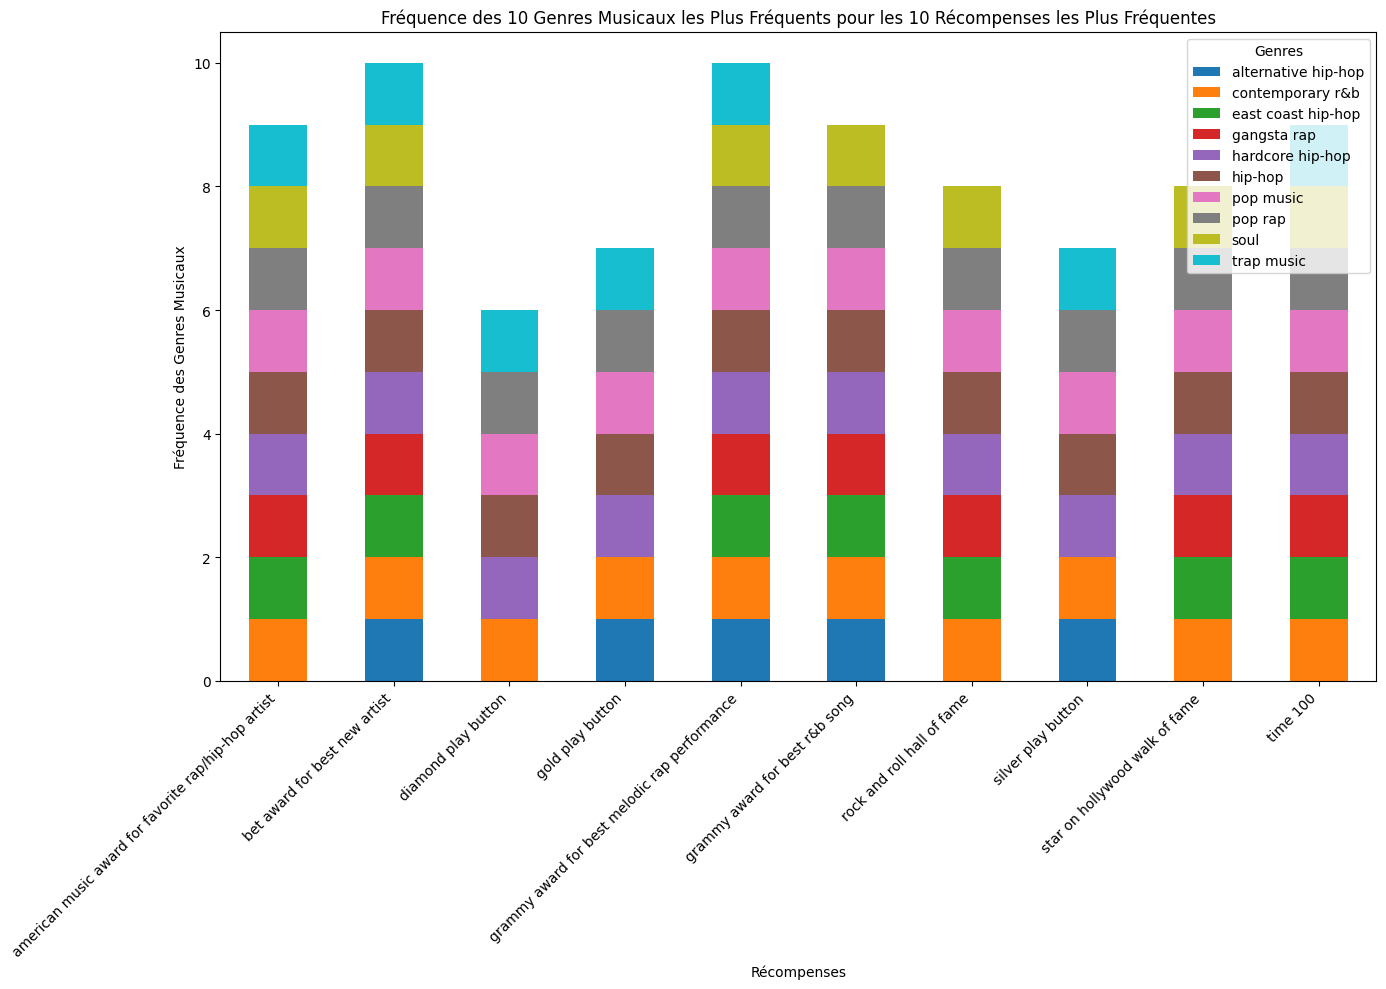

In [39]:
# Sélectionner les 10 genres les plus fréquents
top_genres = genre_award_count.groupby('Genres')['Count'].sum().nlargest(10).index

# Sélectionner les 10 récompenses les plus fréquentes
top_awards = genre_award_count.groupby('Awards')['Count'].sum().nlargest(10).index

# Filtrer les données pour ne garder que ces 10 genres et récompenses
filtered_data = genre_award_count[
    genre_award_count['Genres'].isin(top_genres) & genre_award_count['Awards'].isin(top_awards)
]

# Créer un barplot avec les 10 genres et 10 récompenses les plus fréquents
plt.figure(figsize=(14, 10))
filtered_data.groupby(['Awards', 'Genres'])['Count'].sum().unstack().plot(kind='bar', stacked=True, figsize=(14, 10))

# Ajouter un titre et des labels
plt.title('Fréquence des 10 Genres Musicaux les Plus Fréquents pour les 10 Récompenses les Plus Fréquentes')
plt.xlabel('Récompenses')
plt.ylabel('Fréquence des Genres Musicaux')

# Rotation des labels de l'axe des abscisses pour qu'ils soient plus lisibles
plt.xticks(rotation=45, ha='right')

# Réduire l'espacement entre les labels
plt.tight_layout()

# Afficher le graphique
plt.show()


## Relation entre les labels et le récompences 

<Figure size 1400x1000 with 0 Axes>

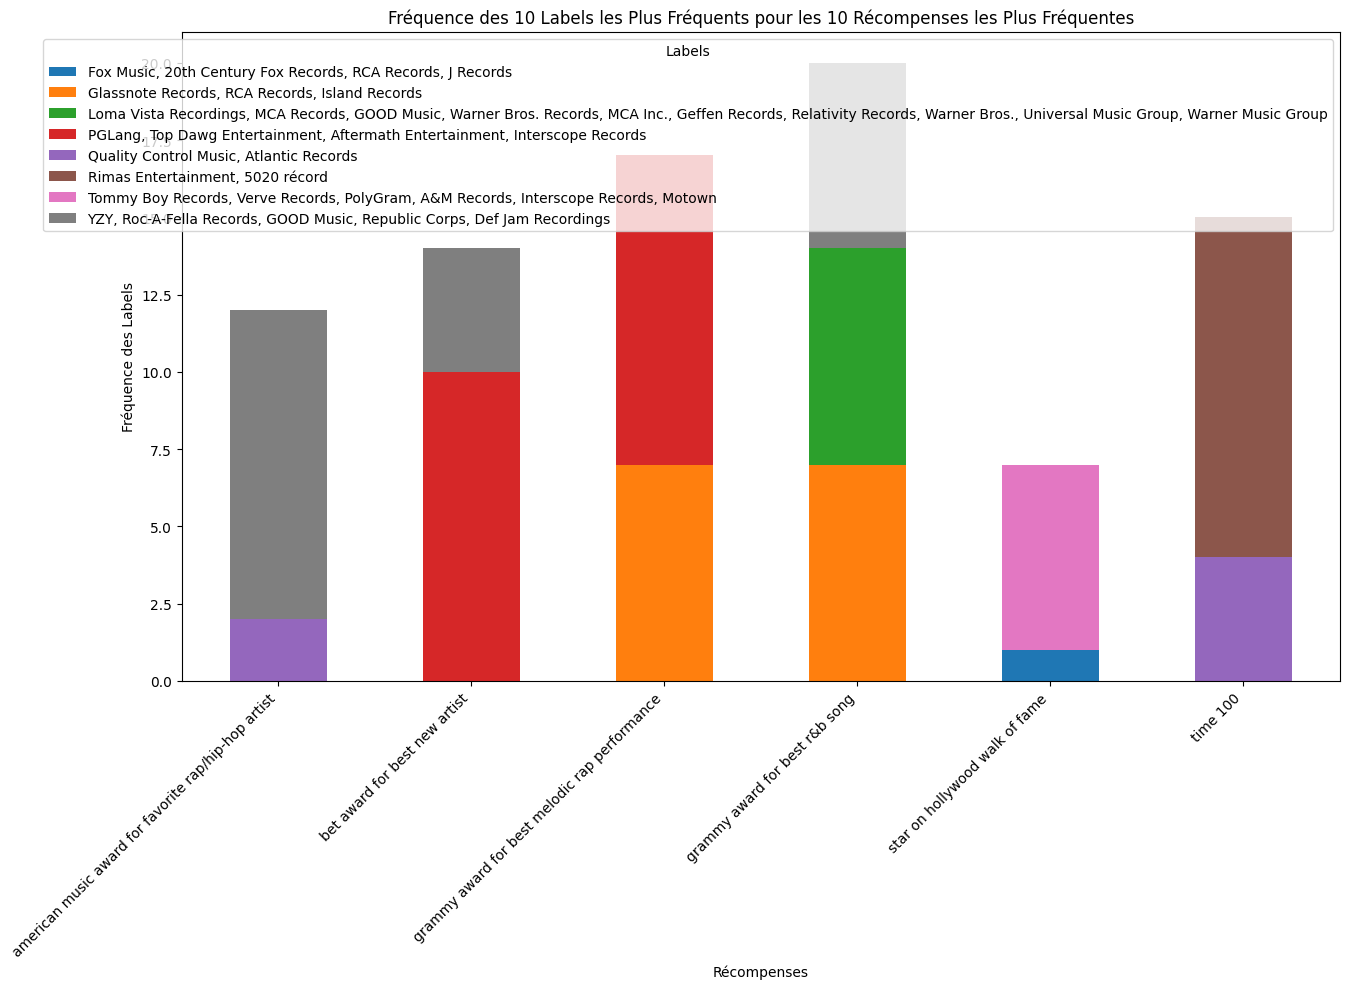

In [43]:
# Créer genre_award_count en utilisant 'Labels' et 'Awards' à partir de df_exploded
genre_award_count = df_exploded.groupby(['Labels', 'Awards']).size().reset_index(name='Count')

# Sélectionner les 10 labels les plus fréquents
top_labels = genre_award_count.groupby('Labels')['Count'].sum().nlargest(10).index

# Sélectionner les 10 récompenses les plus fréquentes
top_awards = genre_award_count.groupby('Awards')['Count'].sum().nlargest(10).index

# Filtrer les données pour ne garder que ces 10 labels et récompenses
filtered_data_labels = genre_award_count[
    genre_award_count['Labels'].isin(top_labels) & genre_award_count['Awards'].isin(top_awards)
]

# Créer un barplot avec les 10 labels et 10 récompenses les plus fréquents
plt.figure(figsize=(14, 10))
filtered_data_labels.groupby(['Awards', 'Labels'])['Count'].sum().unstack().plot(kind='bar', stacked=True, figsize=(14, 10))

# Ajouter un titre et des labels
plt.title('Fréquence des 10 Labels les Plus Fréquents pour les 10 Récompenses les Plus Fréquentes')
plt.xlabel('Récompenses')
plt.ylabel('Fréquence des Labels')

# Rotation des labels de l'axe des abscisses pour qu'ils soient plus lisibles
plt.xticks(rotation=45, ha='right')

# Réduire l'espacement entre les labels
plt.tight_layout()

# Afficher le graphique
plt.show()
